# Learning to Rank: Ordering Results for Search and Recommendation

**Learning to Rank (LTR)** is a machine learning approach for training models to produce an **ordered list** of items relevant to a query. It is the backbone of:

- Web search engines (Google, Bing)
- E-commerce product search (Amazon, eBay)
- Recommendation systems (Netflix, Spotify)
- Question answering (ranking candidate answers)
- Document retrieval and information retrieval

The fundamental insight: **ranking is different from classification or regression**. We do not just want a model that predicts relevance scores; we want a model that correctly orders items relative to each other. An item with score 0.9 above an item with score 0.1 is the same as score 100 above score 1 -- the absolute values do not matter, only the ordering.

**This notebook covers:**
- The three paradigms: Pointwise, Pairwise, Listwise
- Creating a synthetic search dataset with relevance labels
- NDCG (Normalized Discounted Cumulative Gain) from scratch
- LambdaMART with LightGBM (state-of-the-art LTR algorithm)
- MAP (Mean Average Precision) and MRR (Mean Reciprocal Rank)
- Why ranking beats classification for ordered results

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Libraries loaded.')
print(f'LightGBM version: {lgb.__version__}')

Libraries loaded.
LightGBM version: 4.6.0


## 2. The Three Paradigms of Learning to Rank

LTR methods are traditionally grouped into three paradigms based on what the loss function operates on:

### Pointwise
Treat each (query, document) pair independently. Predict a relevance score for each item and optimize a standard regression or classification loss. Simple but ignores the ranking structure -- two documents for the same query are treated as independent examples.

### Pairwise
Operate on pairs of documents for the same query. The model learns to prefer document A over document B (binary classification on pairs). RankSVM, RankBoost, and RankNet use this approach. Better than pointwise because it captures relative ordering, but optimizing pairwise loss does not directly optimize ranking metrics like NDCG.

### Listwise
Optimize the entire ranked list directly, using a metric-aware loss. LambdaMART and ListNet are examples. This is the current state of the art -- it directly optimizes NDCG by modeling the gradient of the ranking metric at the list level.

In [2]:
paradigm_comparison = pd.DataFrame([
    {
        'Paradigm': 'Pointwise',
        'Input to Loss': 'Single (query, doc) pair',
        'Example Algorithms': 'Linear Regression, Ordinal Regression',
        'Pros': 'Simple, uses existing regression/classification tools',
        'Cons': 'Ignores inter-document dependencies; does not optimize ranking metrics'
    },
    {
        'Paradigm': 'Pairwise',
        'Input to Loss': 'Pair of docs for same query',
        'Example Algorithms': 'RankSVM, RankNet, RankBoost',
        'Pros': 'Captures relative ordering; stronger than pointwise',
        'Cons': 'O(n^2) pairs; mismatch between training objective and ranking metric'
    },
    {
        'Paradigm': 'Listwise',
        'Input to Loss': 'Entire ranked list per query',
        'Example Algorithms': 'LambdaMART, ListNet, AdaRank',
        'Pros': 'Directly optimizes ranking metrics (NDCG); best performance',
        'Cons': 'More complex to implement; requires query-level grouping'
    }
])

for _, row in paradigm_comparison.iterrows():
    print(f'=== {row["Paradigm"]} ===')
    for col in paradigm_comparison.columns[1:]:
        print(f'  {col}: {row[col]}')
    print()

=== Pointwise ===
  Input to Loss: Single (query, doc) pair
  Example Algorithms: Linear Regression, Ordinal Regression
  Pros: Simple, uses existing regression/classification tools
  Cons: Ignores inter-document dependencies; does not optimize ranking metrics

=== Pairwise ===
  Input to Loss: Pair of docs for same query
  Example Algorithms: RankSVM, RankNet, RankBoost
  Pros: Captures relative ordering; stronger than pointwise
  Cons: O(n^2) pairs; mismatch between training objective and ranking metric

=== Listwise ===
  Input to Loss: Entire ranked list per query
  Example Algorithms: LambdaMART, ListNet, AdaRank
  Pros: Directly optimizes ranking metrics (NDCG); best performance
  Cons: More complex to implement; requires query-level grouping



## 3. Synthetic Search Dataset

We create a dataset modeled after the Microsoft LETOR benchmark format:
- Multiple queries (search queries)
- Multiple documents per query
- Relevance labels on a 0-4 scale (0=not relevant, 4=perfectly relevant)
- Document features (simulating TF-IDF, BM25, semantic similarity, click features, etc.)

In [3]:
N_QUERIES = 200
DOCS_PER_QUERY = 15
N_FEATURES = 10

feature_names = [
    'bm25_score',         # BM25 relevance score
    'tfidf_cosine',       # TF-IDF cosine similarity
    'semantic_sim',       # Embedding-based similarity
    'page_rank',          # PageRank score of the document
    'click_through_rate', # Historical CTR for this (query, doc) pair
    'dwell_time',         # Average time users spend on this doc for this query
    'title_match',        # Query terms in title (0/1)
    'url_depth',          # URL path depth (lower is often better)
    'freshness',          # Document recency score
    'doc_length_norm'     # Normalized document length
]

rows = []
for query_id in range(N_QUERIES):
    # Base feature matrix for this query
    X_query = np.random.randn(DOCS_PER_QUERY, N_FEATURES)

    # Generate relevance labels based on a weighted combination of features
    # (simulating that relevant docs tend to have better scores)
    true_weights = np.array([0.35, 0.25, 0.20, 0.05, 0.05, 0.03, 0.03, -0.02, 0.01, 0.01])
    latent_relevance = X_query @ true_weights + np.random.randn(DOCS_PER_QUERY) * 0.5

    # Convert to 0-4 ordinal labels
    percentiles = np.percentile(latent_relevance, [40, 60, 75, 90])
    labels = np.zeros(DOCS_PER_QUERY, dtype=int)
    for threshold, label in zip(percentiles, [1, 2, 3, 4]):
        labels[latent_relevance >= threshold] = label

    for doc_id in range(DOCS_PER_QUERY):
        row = {'query_id': query_id, 'doc_id': doc_id, 'relevance': labels[doc_id]}
        for feat_idx, feat_name in enumerate(feature_names):
            row[feat_name] = X_query[doc_id, feat_idx]
        rows.append(row)

df = pd.DataFrame(rows)

print(f'Dataset shape: {df.shape}')
print(f'Number of queries: {df.query_id.nunique()}')
print(f'Documents per query: {DOCS_PER_QUERY}')
print()
print('Relevance label distribution:')
vc = df['relevance'].value_counts().sort_index()
for label, count in vc.items():
    bar = '#' * (count // 20)
    print(f'  Label {label}: {count:4d} ({count/len(df)*100:.1f}%) {bar}')
print()
df.head()

Dataset shape: (3000, 13)
Number of queries: 200
Documents per query: 15

Relevance label distribution:
  Label 0: 1200 (40.0%) ############################################################
  Label 1:  600 (20.0%) ##############################
  Label 2:  400 (13.3%) ####################
  Label 3:  400 (13.3%) ####################
  Label 4:  400 (13.3%) ####################



,query_id,doc_id,relevance,bm25_score,tfidf_cosine,semantic_sim,page_rank,click_through_rate,dwell_time,title_match,url_depth,freshness,doc_length_norm
0,0,0,2,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560
1,0,1,0,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304
2,0,2,1,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694
3,0,3,1,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861
4,0,4,1,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040


## 4. NDCG: Normalized Discounted Cumulative Gain

**NDCG** is the standard evaluation metric for ranking systems. It captures two key ideas:

1. **Highly relevant documents are worth more** (gain is exponential in relevance label)
2. **Relevant documents appearing lower in the ranking are penalized** (discounted by log of position)

**Discounted Cumulative Gain (DCG)**:
$$DCG_k = \sum_{i=1}^{k} \frac{2^{rel_i} - 1}{\log_2(i + 1)}$$

**Ideal DCG (IDCG)**: DCG of the perfect ranking (sorted by descending relevance).

$$NDCG_k = \frac{DCG_k}{IDCG_k}$$

NDCG ranges from 0 to 1. A value of 1 means the model returned results in perfect relevance order.

In [4]:
def dcg_at_k(relevances, k):
    """Compute DCG@k for a single ranked list."""
    relevances = np.array(relevances[:k], dtype=float)
    if len(relevances) == 0:
        return 0.0
    # Positions start at 1; discount = 1 / log2(position + 1)
    positions = np.arange(1, len(relevances) + 1)
    gains = (2 ** relevances - 1) / np.log2(positions + 1)
    return gains.sum()


def ndcg_at_k(relevances, k):
    """Compute NDCG@k for a single ranked list."""
    actual_dcg = dcg_at_k(relevances, k)
    ideal_relevances = sorted(relevances, reverse=True)
    ideal_dcg = dcg_at_k(ideal_relevances, k)
    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg


# Worked example
print('=== NDCG Worked Example ===')
example_ranking = [3, 0, 2, 1, 3]  # relevance of documents at positions 1,2,3,4,5
ideal_ranking = sorted(example_ranking, reverse=True)  # perfect ordering

print(f'Your ranking:  {example_ranking}')
print(f'Ideal ranking: {ideal_ranking}')
print()

print('DCG calculation for your ranking:')
for i, rel in enumerate(example_ranking, 1):
    gain = (2**rel - 1)
    discount = np.log2(i + 1)
    contribution = gain / discount
    print(f'  Position {i}: rel={rel}, gain={gain:.0f}, discount=log2({i+1})={discount:.3f}, contribution={contribution:.4f}')

k = 5
dcg = dcg_at_k(example_ranking, k)
idcg = dcg_at_k(ideal_ranking, k)
ndcg = ndcg_at_k(example_ranking, k)
print(f'\nDCG@{k}  = {dcg:.4f}')
print(f'IDCG@{k} = {idcg:.4f}  (from ideal ranking {ideal_ranking})')
print(f'NDCG@{k} = DCG/IDCG = {dcg:.4f}/{idcg:.4f} = {ndcg:.4f}')

=== NDCG Worked Example ===
Your ranking:  [3, 0, 2, 1, 3]
Ideal ranking: [3, 3, 2, 1, 0]

DCG calculation for your ranking:
  Position 1: rel=3, gain=7, discount=log2(2)=1.000, contribution=7.0000
  Position 2: rel=0, gain=0, discount=log2(3)=1.585, contribution=0.0000
  Position 3: rel=2, gain=3, discount=log2(4)=2.000, contribution=1.5000
  Position 4: rel=1, gain=1, discount=log2(5)=2.322, contribution=0.4307
  Position 5: rel=3, gain=7, discount=log2(6)=2.585, contribution=2.7080

DCG@5  = 11.6386
IDCG@5 = 13.3472  (from ideal ranking [3, 3, 2, 1, 0])
NDCG@5 = DCG/IDCG = 11.6386/13.3472 = 0.8720


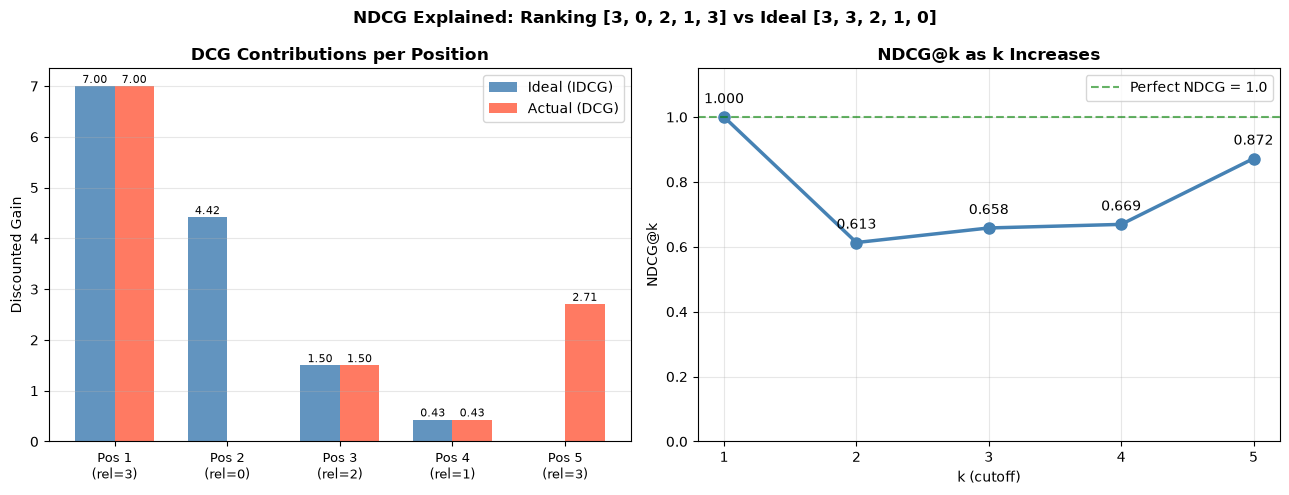

In [5]:
# Visualize NDCG with a bar chart
example_ranking = [3, 0, 2, 1, 3]
ideal_ranking = sorted(example_ranking, reverse=True)

positions = np.arange(1, 6)
discounts = 1 / np.log2(positions + 1)

actual_gains = [(2**r - 1) * d for r, d in zip(example_ranking, discounts)]
ideal_gains = [(2**r - 1) * d for r, d in zip(ideal_ranking, discounts)]

x = np.arange(len(positions))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: contributions per position
ax = axes[0]
bars1 = ax.bar(x - width/2, ideal_gains, width, label='Ideal (IDCG)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, actual_gains, width, label='Actual (DCG)', color='tomato', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'Pos {i}\n(rel={r})' for i, r in enumerate(example_ranking, 1)], fontsize=9)
ax.set_title('DCG Contributions per Position', fontweight='bold')
ax.set_ylabel('Discounted Gain')
ax.legend()
ax.grid(alpha=0.3, axis='y')
for bar in bars1:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# Right: cumulative NDCG
ax = axes[1]
ndcg_at_k_vals = [ndcg_at_k(example_ranking, k) for k in range(1, 6)]
ax.plot(positions, ndcg_at_k_vals, 'o-', color='steelblue', linewidth=2.5, markersize=8)
ax.axhline(1.0, color='green', linestyle='--', alpha=0.6, label='Perfect NDCG = 1.0')
for i, (pos, val) in enumerate(zip(positions, ndcg_at_k_vals)):
    ax.annotate(f'{val:.3f}', (pos, val), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=10)
ax.set_xticks(positions)
ax.set_xlabel('k (cutoff)')
ax.set_ylabel('NDCG@k')
ax.set_title('NDCG@k as k Increases', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle(f'NDCG Explained: Ranking {example_ranking} vs Ideal {ideal_ranking}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train/Validation Split for Ranking

For ranking, splits must be done **at the query level**, not the document level. All documents for a given query must stay together -- otherwise a model could learn to exploit query-level leakage.

In [6]:
# Query-level train/validation/test split
all_query_ids = df['query_id'].unique()
np.random.shuffle(all_query_ids)

n_train = int(0.7 * len(all_query_ids))
n_val = int(0.15 * len(all_query_ids))

train_qids = all_query_ids[:n_train]
val_qids = all_query_ids[n_train:n_train + n_val]
test_qids = all_query_ids[n_train + n_val:]

df_train = df[df['query_id'].isin(train_qids)].copy()
df_val = df[df['query_id'].isin(val_qids)].copy()
df_test = df[df['query_id'].isin(test_qids)].copy()

print('Query-level split:')
print(f'  Train: {len(train_qids)} queries, {len(df_train)} examples')
print(f'  Val:   {len(val_qids)} queries, {len(df_val)} examples')
print(f'  Test:  {len(test_qids)} queries, {len(df_test)} examples')

# Group sizes: number of documents per query (needed by LightGBM)
train_groups = df_train.groupby('query_id').size().values
val_groups = df_val.groupby('query_id').size().values
test_groups = df_test.groupby('query_id').size().values

X_train = df_train[feature_names].values
y_train = df_train['relevance'].values
X_val = df_val[feature_names].values
y_val = df_val['relevance'].values
X_test = df_test[feature_names].values
y_test = df_test['relevance'].values

print(f'\nGroup sizes (documents per query) are used by LightGBM to know query boundaries.')
print(f'Example first 5 group sizes: {train_groups[:5]}')

Query-level split:
  Train: 140 queries, 2100 examples
  Val:   30 queries, 450 examples
  Test:  30 queries, 450 examples

Group sizes (documents per query) are used by LightGBM to know query boundaries.
Example first 5 group sizes: [15 15 15 15 15]


## 6. LambdaMART with LightGBM

**LambdaMART** is the dominant algorithm in LTR. It combines:
- **MART** (Multiple Additive Regression Trees) -- the gradient boosting tree framework
- **Lambda gradients** -- gradients derived not from a differentiable loss but from the change in NDCG when swapping pairs of documents

The key insight of LambdaMART is that NDCG is not differentiable, but we can define the gradient for each pair of documents as:
$$\lambda_{ij} = \frac{|\Delta NDCG_{ij}|}{1 + e^{s_i - s_j}}$$

where delta NDCG is the change in NDCG from swapping documents i and j. This makes the model focus on swaps that matter most for the metric.

LightGBM implements LambdaMART via `objective='lambdarank'`.

In [7]:
# Create LightGBM datasets with group (query) information
train_dataset = lgb.Dataset(
    X_train, label=y_train,
    group=train_groups,
    feature_name=feature_names
)

val_dataset = lgb.Dataset(
    X_val, label=y_val,
    group=val_groups,
    feature_name=feature_names,
    reference=train_dataset
)

# LambdaMART parameters
params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'ndcg_eval_at': [1, 3, 5, 10],  # Evaluate NDCG at these cutoffs
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 10,
    'lambda_l1': 0.0,
    'lambda_l2': 0.1,
    'label_gain': [0, 1, 3, 7, 15],  # Gains for relevance labels 0,1,2,3,4
    'verbose': -1
}

print('Training LambdaMART model...')
callbacks = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(period=50)]

ranker = lgb.train(
    params,
    train_dataset,
    num_boost_round=500,
    valid_sets=[val_dataset],
    valid_names=['val'],
    callbacks=callbacks
)

print(f'\nBest iteration: {ranker.best_iteration}')

Training LambdaMART model...
[50]	val's ndcg@1: 0.56	val's ndcg@3: 0.591118	val's ndcg@5: 0.657877	val's ndcg@10: 0.769285

Best iteration: 26


In [8]:
# Generate ranking scores on test set
scores = ranker.predict(X_test)
df_test = df_test.copy()
df_test['score'] = scores

# Show example query: original order vs ranked order
example_qid = test_qids[0]
q_docs = df_test[df_test['query_id'] == example_qid].copy()

print(f'Example Query ID: {example_qid}')
print(f'Number of documents: {len(q_docs)}')
print()

# Sort by predicted score
q_ranked = q_docs.sort_values('score', ascending=False).reset_index(drop=True)

print('Top 10 documents after ranking (sorted by predicted score):')
print(f'{"Rank":<6} {"Doc ID":<8} {"True Relevance":<16} {"Predicted Score":<18}')
print('-' * 50)
for rank, (_, row) in enumerate(q_ranked.head(10).iterrows(), 1):
    stars = '*' * int(row['relevance'])
    print(f'{rank:<6} {int(row["doc_id"]):<8} {int(row["relevance"])} {stars:<12}  {row["score"]:+.4f}')

Example Query ID: 124
Number of documents: 15

Top 10 documents after ranking (sorted by predicted score):
Rank   Doc ID   True Relevance   Predicted Score   
--------------------------------------------------
1      5        2 **            +0.5137
2      10       3 ***           +0.3894
3      1        3 ***           +0.3368
4      8        0               +0.1550
5      9        4 ****          -0.4110
6      3        2 **            -0.6487
7      7        1 *             -0.7571
8      0        0               -0.8541
9      11       4 ****          -0.8770
10     12       0               -0.8978


## 7. Feature Importance

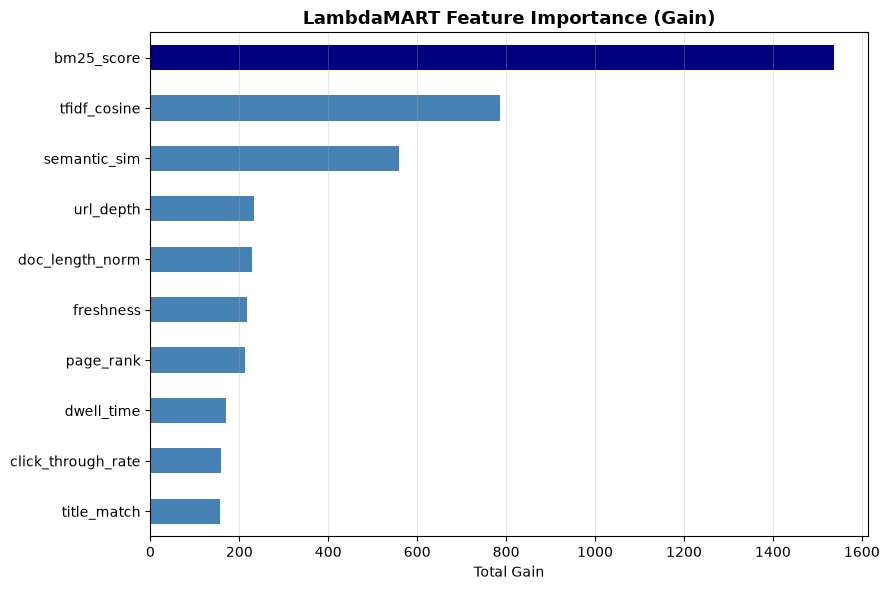

Top 5 most important features:
  bm25_score                gain = 1536.4
  tfidf_cosine              gain = 786.1
  semantic_sim              gain = 559.8
  url_depth                 gain = 233.2
  doc_length_norm           gain = 227.7


In [9]:
# Feature importance
importances = ranker.feature_importance(importance_type='gain')
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['steelblue' if v < feat_imp.max() * 0.6 else 'navy' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('LambdaMART Feature Importance (Gain)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Gain')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f'  {feat:<25} gain = {imp:.1f}')

## 8. Evaluation Metrics: NDCG, MAP, MRR

In [10]:
def average_precision_at_k(relevances, k, threshold=1):
    """
    Compute Average Precision at k.
    A document is considered relevant if its relevance >= threshold.
    """
    relevances = relevances[:k]
    if len(relevances) == 0:
        return 0.0
    score = 0.0
    num_hits = 0.0
    for i, rel in enumerate(relevances, 1):
        if rel >= threshold:
            num_hits += 1
            score += num_hits / i  # precision at this position
    n_relevant_total = sum(r >= threshold for r in relevances)
    if n_relevant_total == 0:
        return 0.0
    return score / n_relevant_total


def reciprocal_rank(relevances, threshold=1):
    """
    Compute Reciprocal Rank: 1/rank of first relevant document.
    Returns 0 if no relevant document is found.
    """
    for i, rel in enumerate(relevances, 1):
        if rel >= threshold:
            return 1.0 / i
    return 0.0


def evaluate_ranking(df_scored, query_col='query_id', label_col='relevance',
                     score_col='score', k=10, threshold=1):
    """
    Compute NDCG@k, MAP@k, and MRR across all queries.
    """
    ndcg_scores, ap_scores, rr_scores = [], [], []

    for qid, group in df_scored.groupby(query_col):
        ranked = group.sort_values(score_col, ascending=False)
        rels = ranked[label_col].values

        ndcg_scores.append(ndcg_at_k(rels, k))
        ap_scores.append(average_precision_at_k(rels, k, threshold))
        rr_scores.append(reciprocal_rank(rels, threshold))

    return {
        f'NDCG@{k}': np.mean(ndcg_scores),
        f'MAP@{k}': np.mean(ap_scores),
        'MRR': np.mean(rr_scores)
    }


print('=== Evaluation on Test Set ===')
print()

# LambdaMART ranker
ranker_metrics = evaluate_ranking(df_test, k=10)
print('LambdaMART (LightGBM):')
for metric, val in ranker_metrics.items():
    print(f'  {metric}: {val:.4f}')
print()

=== Evaluation on Test Set ===

LambdaMART (LightGBM):
  NDCG@10: 0.7714
  MAP@10: 0.9282
  MRR: 1.0000



In [11]:
# Compare against baselines
# Baseline 1: BM25 only ranking (single feature)
df_bm25 = df_test.copy()
df_bm25['score'] = df_bm25['bm25_score']
bm25_metrics = evaluate_ranking(df_bm25, k=10)

# Baseline 2: Random ranking
df_random = df_test.copy()
df_random['score'] = np.random.randn(len(df_random))
random_metrics = evaluate_ranking(df_random, k=10)

# Baseline 3: Pointwise (logistic regression on relevance as binary)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)
y_tr_binary = (y_train >= 1).astype(int)  # pointwise: relevant vs not

lr = LogisticRegression(max_iter=300, C=1.0)
lr.fit(X_tr_scaled, y_tr_binary)
pointwise_scores = lr.predict_proba(X_te_scaled)[:, 1]

df_pointwise = df_test.copy()
df_pointwise['score'] = pointwise_scores
pointwise_metrics = evaluate_ranking(df_pointwise, k=10)

print('Model Comparison:')
print(f'{"Model":<30} {"NDCG@10":>10} {"MAP@10":>10} {"MRR":>10}')
print('-' * 62)
for name, metrics in [
    ('Random Baseline', random_metrics),
    ('BM25 Single Feature', bm25_metrics),
    ('Pointwise (Logistic Reg)', pointwise_metrics),
    ('LambdaMART (LightGBM)', ranker_metrics)
]:
    print(f'{name:<30} {metrics["NDCG@10"]:>10.4f} {metrics["MAP@10"]:>10.4f} {metrics["MRR"]:>10.4f}')

Model Comparison:
Model                             NDCG@10     MAP@10        MRR
--------------------------------------------------------------
Random Baseline                    0.4394     0.6785     0.7444
BM25 Single Feature                0.7300     0.8882     0.9833
Pointwise (Logistic Reg)           0.7996     0.9459     1.0000
LambdaMART (LightGBM)              0.7714     0.9282     1.0000


## 9. MAP and MRR Explained

**Mean Average Precision (MAP)** and **Mean Reciprocal Rank (MRR)** are simpler ranking metrics commonly used in information retrieval.

In [12]:
# Worked examples for MAP and MRR
print('=== MAP (Mean Average Precision) ===')
print()
print('Setup: 1 = relevant, 0 = not relevant')
print()

ranked_results = [1, 0, 1, 1, 0]  # binary relevance at positions 1-5
print(f'Ranked result list: {ranked_results}')
print()

hits = 0
precision_at_rel = []
for i, rel in enumerate(ranked_results, 1):
    if rel == 1:
        hits += 1
        p_at_i = hits / i
        precision_at_rel.append(p_at_i)
        print(f'  Position {i}: RELEVANT. Hits so far = {hits}. Precision@{i} = {hits}/{i} = {p_at_i:.3f}')
    else:
        print(f'  Position {i}: not relevant (skip)')

ap = np.mean(precision_at_rel)
print(f'\nAverage Precision = mean({[f"{p:.3f}" for p in precision_at_rel]}) = {ap:.3f}')
print('MAP = mean of AP across multiple queries')

print()
print('=== MRR (Mean Reciprocal Rank) ===')
print()
print('MRR is used when only the FIRST relevant result matters (e.g., navigational queries).')
print()

queries_results = [
    [0, 1, 0, 0, 1],  # first relevant at position 2
    [0, 0, 1, 0, 0],  # first relevant at position 3
    [1, 0, 0, 0, 0],  # first relevant at position 1
]

rrs = []
for q_idx, results in enumerate(queries_results, 1):
    for i, rel in enumerate(results, 1):
        if rel == 1:
            rr = 1.0 / i
            rrs.append(rr)
            print(f'  Query {q_idx}: First relevant at position {i}. RR = 1/{i} = {rr:.3f}')
            break

print(f'\nMRR = mean({[f"{r:.3f}" for r in rrs]}) = {np.mean(rrs):.3f}')

=== MAP (Mean Average Precision) ===

Setup: 1 = relevant, 0 = not relevant

Ranked result list: [1, 0, 1, 1, 0]

  Position 1: RELEVANT. Hits so far = 1. Precision@1 = 1/1 = 1.000
  Position 2: not relevant (skip)
  Position 3: RELEVANT. Hits so far = 2. Precision@3 = 2/3 = 0.667
  Position 4: RELEVANT. Hits so far = 3. Precision@4 = 3/4 = 0.750
  Position 5: not relevant (skip)

Average Precision = mean(['1.000', '0.667', '0.750']) = 0.806
MAP = mean of AP across multiple queries

=== MRR (Mean Reciprocal Rank) ===

MRR is used when only the FIRST relevant result matters (e.g., navigational queries).

  Query 1: First relevant at position 2. RR = 1/2 = 0.500
  Query 2: First relevant at position 3. RR = 1/3 = 0.333
  Query 3: First relevant at position 1. RR = 1/1 = 1.000

MRR = mean(['0.500', '0.333', '1.000']) = 0.611


## 10. Why Ranking Beats Classification for Ordered Results

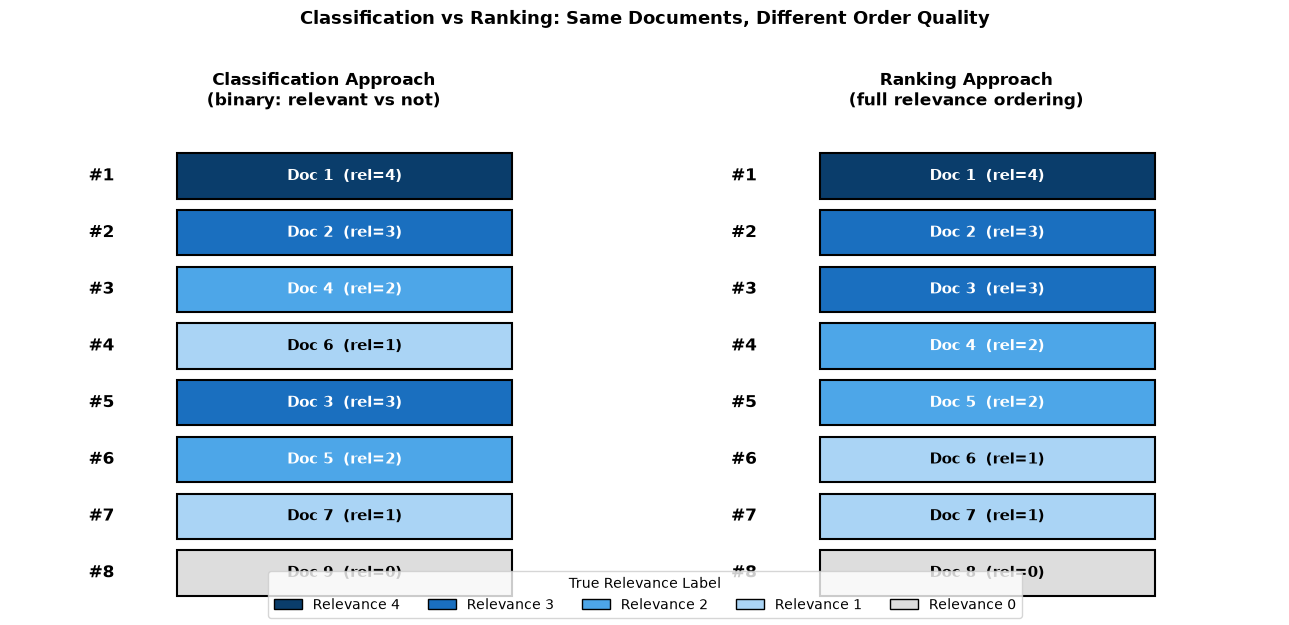

In [13]:
# Visualize the problem: classification does not care about order within relevant set
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

n_items = 10
true_relevance = [4, 3, 3, 2, 2, 1, 1, 0, 0, 0]

# Classification approach: binary scores, no ordering within relevant
classif_scores = [0.92, 0.88, 0.55, 0.82, 0.45, 0.72, 0.30, 0.15, 0.20, 0.10]
classif_order = np.argsort(classif_scores)[::-1]

# Ranking approach: scores respect full relevance order
ranking_scores = [0.95, 0.85, 0.82, 0.70, 0.65, 0.45, 0.35, 0.20, 0.12, 0.05]
rank_order = np.argsort(ranking_scores)[::-1]

cmap = {0: '#dddddd', 1: '#aad4f5', 2: '#4da6e8', 3: '#1a6fbf', 4: '#0a3d6b'}

for ax, order, title in [
    (axes[0], classif_order, 'Classification Approach\n(binary: relevant vs not)'),
    (axes[1], rank_order, 'Ranking Approach\n(full relevance ordering)')
]:
    for rank, doc_idx in enumerate(order[:8]):
        rel = true_relevance[doc_idx]
        color = cmap[rel]
        rect = plt.Rectangle((0.1, 7 - rank), 0.8, 0.8, color=color,
                              ec='black', lw=1.5, zorder=2)
        ax.add_patch(rect)
        ax.text(0.5, 7.4 - rank, f'Doc {doc_idx+1}  (rel={rel})',
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if rel >= 2 else 'black')
        ax.text(-0.05, 7.4 - rank, f'#{rank+1}', ha='right', va='center',
                fontsize=12, fontweight='bold')

    ax.set_xlim(-0.3, 1.2)
    ax.set_ylim(-0.2, 8.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

# Legend
patches = [mpatches.Patch(color=cmap[r], label=f'Relevance {r}', ec='black')
           for r in [4, 3, 2, 1, 0]]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=10,
           title='True Relevance Label')

classif_ndcg = ndcg_at_k([true_relevance[i] for i in classif_order], 5)
rank_ndcg = ndcg_at_k([true_relevance[i] for i in rank_order], 5)

axes[0].set_xlabel(f'NDCG@5 = {classif_ndcg:.3f}', fontsize=12)
axes[1].set_xlabel(f'NDCG@5 = {rank_ndcg:.3f}', fontsize=12)

plt.suptitle('Classification vs Ranking: Same Documents, Different Order Quality',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Real-World Use Cases

In [14]:
use_cases = [
    {
        'Domain': 'Web Search',
        'Query': 'User types a search query',
        'Items': 'Web pages in the index',
        'Features': 'BM25, PageRank, CTR, anchor text, semantic similarity',
        'Key Metric': 'NDCG@10, MRR (for navigational queries)',
        'Algorithm': 'LambdaMART (Google, Bing) or neural LTR (BERT-based)'
    },
    {
        'Domain': 'E-Commerce',
        'Query': 'User searches for a product',
        'Items': 'Product catalog',
        'Features': 'Text match, price, reviews, CTR, purchase rate, inventory',
        'Key Metric': 'Revenue-weighted NDCG, conversion rate',
        'Algorithm': 'LambdaMART with business constraints'
    },
    {
        'Domain': 'Recommendation',
        'Query': 'User context (history, demographics)',
        'Items': 'Movies, songs, articles',
        'Features': 'Collaborative filtering scores, content features, diversity',
        'Key Metric': 'NDCG@K, precision@K, diversity',
        'Algorithm': 'Two-stage: recall (ANN search) then LTR reranker'
    },
    {
        'Domain': 'Question Answering',
        'Query': 'Natural language question',
        'Items': 'Candidate answer passages',
        'Features': 'Dense retrieval score, NLI score, passage length',
        'Key Metric': 'MRR@10, MAP',
        'Algorithm': 'Cross-encoder reranker (BERT + LambdaMART)'
    }
]

for uc in use_cases:
    print(f'--- {uc["Domain"]} ---')
    for k, v in uc.items():
        if k != 'Domain':
            print(f'  {k}: {v}')
    print()

--- Web Search ---
  Query: User types a search query
  Items: Web pages in the index
  Features: BM25, PageRank, CTR, anchor text, semantic similarity
  Key Metric: NDCG@10, MRR (for navigational queries)
  Algorithm: LambdaMART (Google, Bing) or neural LTR (BERT-based)

--- E-Commerce ---
  Query: User searches for a product
  Items: Product catalog
  Features: Text match, price, reviews, CTR, purchase rate, inventory
  Key Metric: Revenue-weighted NDCG, conversion rate
  Algorithm: LambdaMART with business constraints

--- Recommendation ---
  Query: User context (history, demographics)
  Items: Movies, songs, articles
  Features: Collaborative filtering scores, content features, diversity
  Key Metric: NDCG@K, precision@K, diversity
  Algorithm: Two-stage: recall (ANN search) then LTR reranker

--- Question Answering ---
  Query: Natural language question
  Items: Candidate answer passages
  Features: Dense retrieval score, NLI score, passage length
  Key Metric: MRR@10, MAP
  Algo

## 12. Key Takeaways

Learning to Rank is the right tool whenever **the relative order of items matters more than their absolute scores**. Here is the summary:

| Concept | Summary |
|---------|--------|
| **Pointwise** | Treats each item independently; easiest to implement but worst at ranking |
| **Pairwise** | Learns relative preferences; better than pointwise |
| **Listwise (LambdaMART)** | Optimizes the ranked list directly; best performance |
| **NDCG** | Primary metric; penalizes relevant items at lower positions; range [0,1] |
| **MAP** | Average precision across relevant items; good for binary relevance |
| **MRR** | Reciprocal rank of first hit; best for navigational/single-answer queries |
| **LightGBM** | `objective='lambdarank'` with `group` parameter; most practical LTR implementation |

**Practical tips**:
1. Always split train/val/test at the **query level**, not the document level
2. The `group` parameter in LightGBM is the number of documents per query -- critical for LambdaMART
3. Use `label_gain` to specify NDCG gains for your relevance scale (default works for 0-4)
4. Evaluate at multiple cutoffs (NDCG@1, @5, @10) -- different cutoffs reveal different problems
5. In production, LTR is typically a **reranker** on top of a fast retrieval stage (BM25 or ANN search)